In [1]:
# %load ../init.ipy
%reload_ext autoreload
%autoreload 2
from importlib import reload

import numpy as np
import matplotlib.cm as cm

import holodeck as holo
from holodeck import plot, utils, sams
from holodeck.constants import YR

# Build Semi-Analytic Model, sam
Select a shape (smaller for speed, larger for accuracy, best with None) and use defaults for all other parameters (GSMF, GMT, MMbulge) in sam

In [2]:
# SHAPE = None # default shape, if None, is 91,81,101.
SHAPE = np.int64(40)  # make this smaller to run faster, for debugging

# get PTA frequencies
fobs_gw_cents, fobs_gw_edges = utils.pta_freqs()

# build Semi-Analytic Model
sam = holo.sams.Semi_Analytic_Model(shape=SHAPE)  

18:00:56 INFO : No galaxy pair-fraction given, using galaxy merger-rate. [sam.py:__init__]


# Calculate SS and GWB strain with sam.gwb()
This function calls single_sources.ss_gws_redz().

### Choose a hardening model

In [3]:
# uncomment one of the following hardening models

# # GW only hardening
hard=holo.hardening.Hard_GW()

# # Fixed Time (phenomenological) hardening
# hard = holo.hardening.Fixed_Time_2PL_SAM(sam, 3*GYR)

assert isinstance(hard, (holo.hardening.Fixed_Time_2PL_SAM, holo.hardening.Hard_GW))

### Set the number of realizations and loudest sources

In [4]:
NREALS = np.int64(30) # Set the number of strain realizations
NLOUDEST = np.int64(10) # set the number of loudest single sources to distinguish at each frequency

### Calculate the characteristic strain of the single sources and background
* hc_ss is shape [F,R,L] = [nfrequencies, nreals, nloudest], and gives the characteristic strain of each individual loudest source
* hc_bg is shape [F,R] and gives the sum of the char strain from all other sources at each frequency

In [5]:
hc_ss, hc_bg, = sam.gwb(fobs_gw_edges, hard=hard, 
                        realize = NREALS, loudest = NLOUDEST)

18:01:03 INFO : No GMT was provided, cannot calculate Galaxy-Merger based stalling. [sam.py:static_binary_density]
18:01:03 INFO : Adding MMbulge scatter (2.8000e-01) [sam.py:static_binary_density]
18:01:03 INFO : 	dens bef: (4.20e-277, 1.13e-122, 2.39e-24, 3.13e-03, 2.19e-01, 1.02e+00, 4.54e+00) [sam.py:static_binary_density]
18:01:18 INFO : Scatter added after 15.060234 sec [sam.py:static_binary_density]
18:01:18 INFO : 	dens aft: (1.25e-26, 9.65e-13, 4.71e-08, 4.83e-03, 3.29e-01, 1.08e+00, 4.17e+00) [sam.py:static_binary_density]
18:01:18 INFO : 	mass: 2.23e-01 ==> 3.16e-01 || change = 4.1648e-01 [sam.py:static_binary_density]
18:01:18 ERROR : Warning, significant change in number-mass!  mass: 2.23e-01 ==> 3.16e-01 || change = 4.1648e-01 [sam.py:static_binary_density]
18:01:18 INFO : `redz_prime` not calculated in SAM.  Setting to `redz` (initial) values. [sam.py:gwb]


### Plot

<Axes: xlabel='GW Frequency $[\\mathrm{nHz}]$'>

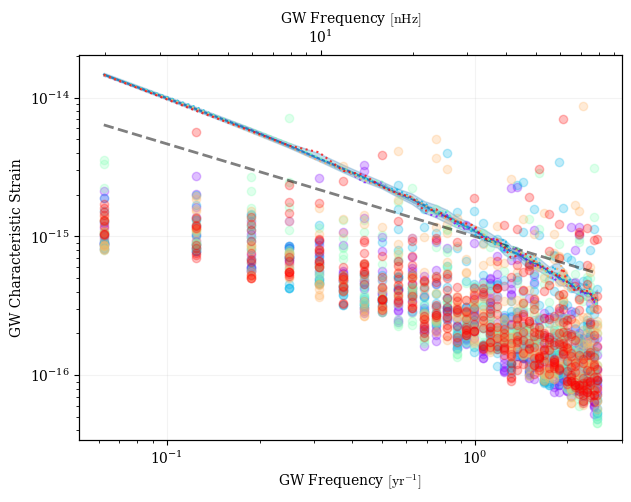

In [10]:
nsamp = 5

fig, ax = plot.figax(xlabel=plot.LABEL_GW_FREQUENCY_YR, ylabel = plot.LABEL_CHARACTERISTIC_STRAIN)

xx = fobs_gw_cents*YR
yy = 1e-15 * np.power(xx, -2.0/3.0)

# plot power law, for comparison
ax.plot(xx, yy, 'k--', alpha=0.5, lw=2.0)

# plot background median and confidence intervals
ax.plot(xx, np.median(hc_bg, axis=-1), color='tab:blue', alpha = 0.9)
for pp in [50, 95]:
    percs = [50-pp/2, 50+pp/2]
    ax.fill_between(xx, *np.percentile(hc_bg, percs, axis=-1), alpha=0.25, color='tab:blue')

# plot random realizations
nsamp = np.min([nsamp, NREALS])
colors = cm.rainbow(np.linspace(0,1,nsamp))
idx = np.random.choice(NREALS, nsamp, replace=False)

ci = 0
for ii in idx:
    # background
    ax.plot(xx, hc_bg[:,ii], ':', color=colors[ci], alpha=0.75)

    # single sources
    ax.scatter(np.repeat(xx, NLOUDEST), hc_ss[:,ii,:].flatten(), alpha=0.25, color=colors[ci])
    ci += 1

# Add nHz axis
plot._twin_hz(ax, nano=True)